In [2]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
import scipy.sparse as sp

In [4]:
import time
import numpy as np
from numpy import bool_
from numpy import sqrt
from numpy import int64
from numpy import float64
from numba import njit
from numba import objmode
from numpy.linalg import norm
@njit(cache=True)
def local_appr(n, indptr, indices, degree, s, alpha, eps, opt_x=None):
    with objmode(start='f8'):
        start = time.perf_counter()
    # --- initialization ---
    xt = np.zeros(n, dtype=float64)
    rt = np.zeros(n, dtype=float64)
    rt[:] = s
    eps_vec = eps * degree
    # ----------------------
    # queue data structure
    st = np.nonzero(s)[0]
    front = int64(0)
    queue = np.zeros(n + 1, dtype=int64)
    queue[:len(st)] = st
    q_mark = np.zeros(n + 1, dtype=bool_)
    q_mark[st] = True
    rear = len(st)
    queue[rear] = n  # iteration flag
    q_mark[n] = True
    rear += 1

    # results
    errs = []
    opers = []
    cd_xt = []
    cd_rt = []
    vol_st = []
    vol_it = []
    gamma_t = []
    op_time = np.float64(0.)
    oper = 0.
    with objmode(debug_start='f8'):
        debug_start = time.perf_counter()
    gamma_pre = np.linalg.norm(s, 1)
    gamma = 0.
    with objmode(op_time='f8'):
        op_time += (time.perf_counter() - debug_start)

    while True:
        u = queue[front]
        q_mark[u] = False
        front = (front + 1) % n
        if u == n:  # one local iteration
            # ------ debug time ------
            with objmode(debug_start='f8'):
                debug_start = time.perf_counter()
            if opt_x is not None:
                errs.append(norm(xt - opt_x, 1))
            else:
                errs.append(np.infty)  # fakes
            opers.append(oper)
            cd_xt.append(np.count_nonzero(xt))
            cd_rt.append(np.count_nonzero(rt))
            vol_st.append(oper)
            vol_it.append(np.sum(degree[np.nonzero(rt)]))
            gamma_t.append(gamma / gamma_pre)
            oper = 0.
            gamma = 0.
            gamma_pre = np.linalg.norm(rt, 1)
            with objmode(op_time='f8'):
                op_time += (time.perf_counter() - debug_start)
            # ------------------------

            queue[rear] = n
            rear = (rear + 1) % n
            continue

        oper += degree[u]
        gamma += np.abs(rt[u])

        delta = .5 * (1. - alpha) * rt[u]
        xt[u] += alpha * rt[u]
        rt[u] = delta
        for v in indices[indptr[u]:indptr[u + 1]]:
            rt[v] += delta / degree[u]
            if not q_mark[v] and eps_vec[v] <= rt[v]:
                queue[rear] = v
                q_mark[v] = True
                rear = (rear + 1) % n
        # only iteration flag left, quit
        if (rear - front) == 1:
            if len(errs) != 0:
                break
            # ------ debug time ------
            with objmode(debug_start='f8'):
                debug_start = time.perf_counter()
            if opt_x is not None:
                errs.append(norm(xt - opt_x, 1))
            else:
                errs.append(np.infty)  # fakes
            opers.append(oper)
            cd_xt.append(np.count_nonzero(xt))
            cd_rt.append(np.count_nonzero(rt))
            vol_st.append(oper)
            vol_it.append(np.sum(degree[np.nonzero(rt)]))
            gamma_t.append(gamma / gamma_pre)
            with objmode(op_time='f8'):
                op_time += (time.perf_counter() - debug_start)
            break
            # ------------------------
    with objmode(run_time='f8'):
        run_time = time.perf_counter() - start
    return xt, rt, errs, opers, cd_xt, cd_rt, vol_st, vol_it, gamma_t, run_time, op_time



In [9]:


@njit(cache=True)
def grad_gt(indptr, indices, sqrt_deg, s, xt, st, st_count, alpha, rho):
    grad_xt = alpha * (rho * sqrt_deg - s / sqrt_deg)
    for i in np.arange(st_count):
        ii = st[i]
        grad_xt[ii] += .5 * (1. + alpha) * xt[ii]
        for v in indices[indptr[ii]:indptr[ii + 1]]:
            demon = sqrt_deg[v] * sqrt_deg[ii]
            grad_xt[v] -= .5 * (1. - alpha) * xt[ii] / demon
    return grad_xt



@njit(cache=True)
def apgd(indptr, indices, sqrt_deg, alpha, st, st_count, x0, t, s, rho):
    at_pre = 0.
    at = 1.
    yt = np.copy(x0)
    zt = np.copy(x0)
    kappa = 1. / alpha
    for _ in np.arange(t):
        at_next = at_pre + at
        xt = (at_pre / at_next) * yt + (at / at_next) * zt
        coeff_1 = (kappa - 1. + at_pre) / (kappa - 1. + at_next)
        coeff_2 = at / (kappa - 1. + at_next)
        grad_xt = grad_gt(indptr, indices, sqrt_deg, s, xt, st, st_count, alpha, rho)
        tmp_zt = coeff_1 * zt + coeff_2 * (xt - grad_xt / alpha)
        zt = np.zeros(len(xt))
        for j in np.arange(st_count):
            if tmp_zt[st[j]] > 0:
                zt[st[j]] = tmp_zt[st[j]]
        yt = (at_pre / at_next) * yt + (at / at_next) * zt
        at = at_next * (2. * kappa / (2. * kappa + 1. - np.sqrt(1. + 4 * kappa)) - 1.)
        at_pre = at_next
    return yt



@njit(cache=True)
def var_appr_aspr(n, indptr, indices, degree, s, alpha, eps, rho, opt_x):
    xt = np.zeros(n, dtype=np.float64)
    st = np.zeros(n, dtype=np.int64)
    st_flag = np.zeros(n, dtype=np.bool_)
    sqrt_deg = np.sqrt(degree)
    st_count = 0
    new_counts = 0
    for i in np.arange(n):
        if s[i] > rho * degree[i]:
            st[st_count] = i
            st_flag[i] = True
            st_count += 1
            new_counts += 1
    l1_error = []
    nonzero_list = []
    st_list = []
    while new_counts != 0:
        grad_xt = grad_gt(indptr, indices, sqrt_deg, s, xt, st, st_count, alpha, rho)
        delta_t = np.sqrt((eps * alpha) / (1. + st_count))
        eps_t_hat = (alpha * (delta_t ** 2.)) / 2.
        num = (1. - alpha) * np.sum(grad_xt[st[:st_count]] ** 2.)
        dem = 2. * eps_t_hat * (alpha ** 2.)
        t = 1. + np.ceil(2. * np.sqrt(1. / alpha) * np.log(num / dem))
        xt_bar = apgd(indptr, indices, sqrt_deg, alpha, st, st_count, xt, t, s, rho)
        for i in np.arange(st_count):
            node = st[i]
            xt[node] = np.max(np.array([np.float64(0.), np.float64(xt_bar[node] - delta_t)]))
        grad_xt = grad_gt(indptr, indices, sqrt_deg, s, xt, st, st_count, alpha, rho)
        st_count_old = st_count
        for i in np.arange(n):
            if grad_xt[i] < 0. and not st_flag[i]:
                st[st_count] = i
                st_count += 1
                st_flag[i] = True
        new_counts = st_count - st_count_old
        if opt_x is not None:
            nonzero_list.append(np.count_nonzero(xt))
            l1_error.append(np.linalg.norm(xt * sqrt_deg - opt_x, 1))
            st_list.append((t + 1.) * np.sum(degree[st[:st_count]]))
    return sqrt_deg * xt, l1_error, nonzero_list, st_list


0.9999952720403966
0.9589211207215025
0.9755076596470342


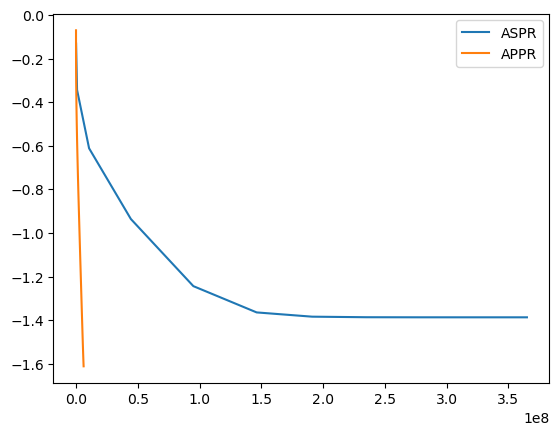

In [10]:
adj_m = sp.load_npz('XXX/datasets/com-dblp/com-dblp_csr-mat.npz')
degree = np.int32(adj_m.sum(1).A.flatten())
indices = adj_m.indices
indptr = adj_m.indptr
n = len(degree)
alpha = 0.15
eps = 0.1 / n
seed_node = 0
s = np.zeros(n)
s[seed_node] = 1.
re_ = local_appr(n, indptr, indices, degree, s, alpha, eps=1e-6 / n, opt_x=None)
opt_xt, rt, errs, opers, cd_xt, cd_rt, vol_st, vol_it, gamma_t, run_time, op_time = re_
print(np.linalg.norm(opt_xt, 1))

re_aspr = var_appr_aspr(n, indptr, indices, degree, s, alpha, eps=eps * 1e-1, rho=eps, opt_x=opt_xt)
xt, l1_error, nonzero_list, st_list = re_aspr
print(np.linalg.norm(xt, 1))
plt.plot(np.cumsum(st_list), np.log10(l1_error), label="ASPR")

re_ = local_appr(n, indptr, indices, degree, s, alpha, eps, opt_x=opt_xt)
xt, rt, errs, opers, cd_xt, cd_rt, vol_st, vol_it, gamma_t, run_time, op_time = re_
print(np.linalg.norm(xt, 1))
plt.plot(np.cumsum(opers), np.log10(errs), label="APPR")
plt.legend()
plt.show()